# Task - 1

Implement a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.
Dataset :[Click here ][def]

[def]: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction/data

## Downloading the Dataset

In [1]:
import kagglehub
import shutil
import os

# Define your desired destination folder
destination_folder = r"E:\VS Code\ProdiyInfoTech"  # Change this path as you want

# Download latest version using kagglehub
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Move files from kagglehub's cache to your desired folder
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join(destination_folder, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset copied to:", destination_folder)


e:\VS Code\ProdiyInfoTech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 780k/780k [00:01<00:00, 658kB/s]

Extracting files...
Dataset copied to: E:\VS Code\ProdiyInfoTech


In [1]:
import tensorflow as tf

In [2]:
from tensorflow import keras
print("success")

success


In [4]:
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns

## Data Processing


In [5]:
dataset= pd.read_csv("E:\VS Code\ProdiyInfoTech\kc_house_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\V'
<>:1: SyntaxWarning: invalid escape sequence '\V'
C:\Users\asus\AppData\Local\Temp\ipykernel_4636\1766909724.py:1: SyntaxWarning: invalid escape sequence '\V'
  dataset= pd.read_csv("E:\VS Code\ProdiyInfoTech\kc_house_data.csv")


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [9]:
dataset.describe(include="all")

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


### Plot the data

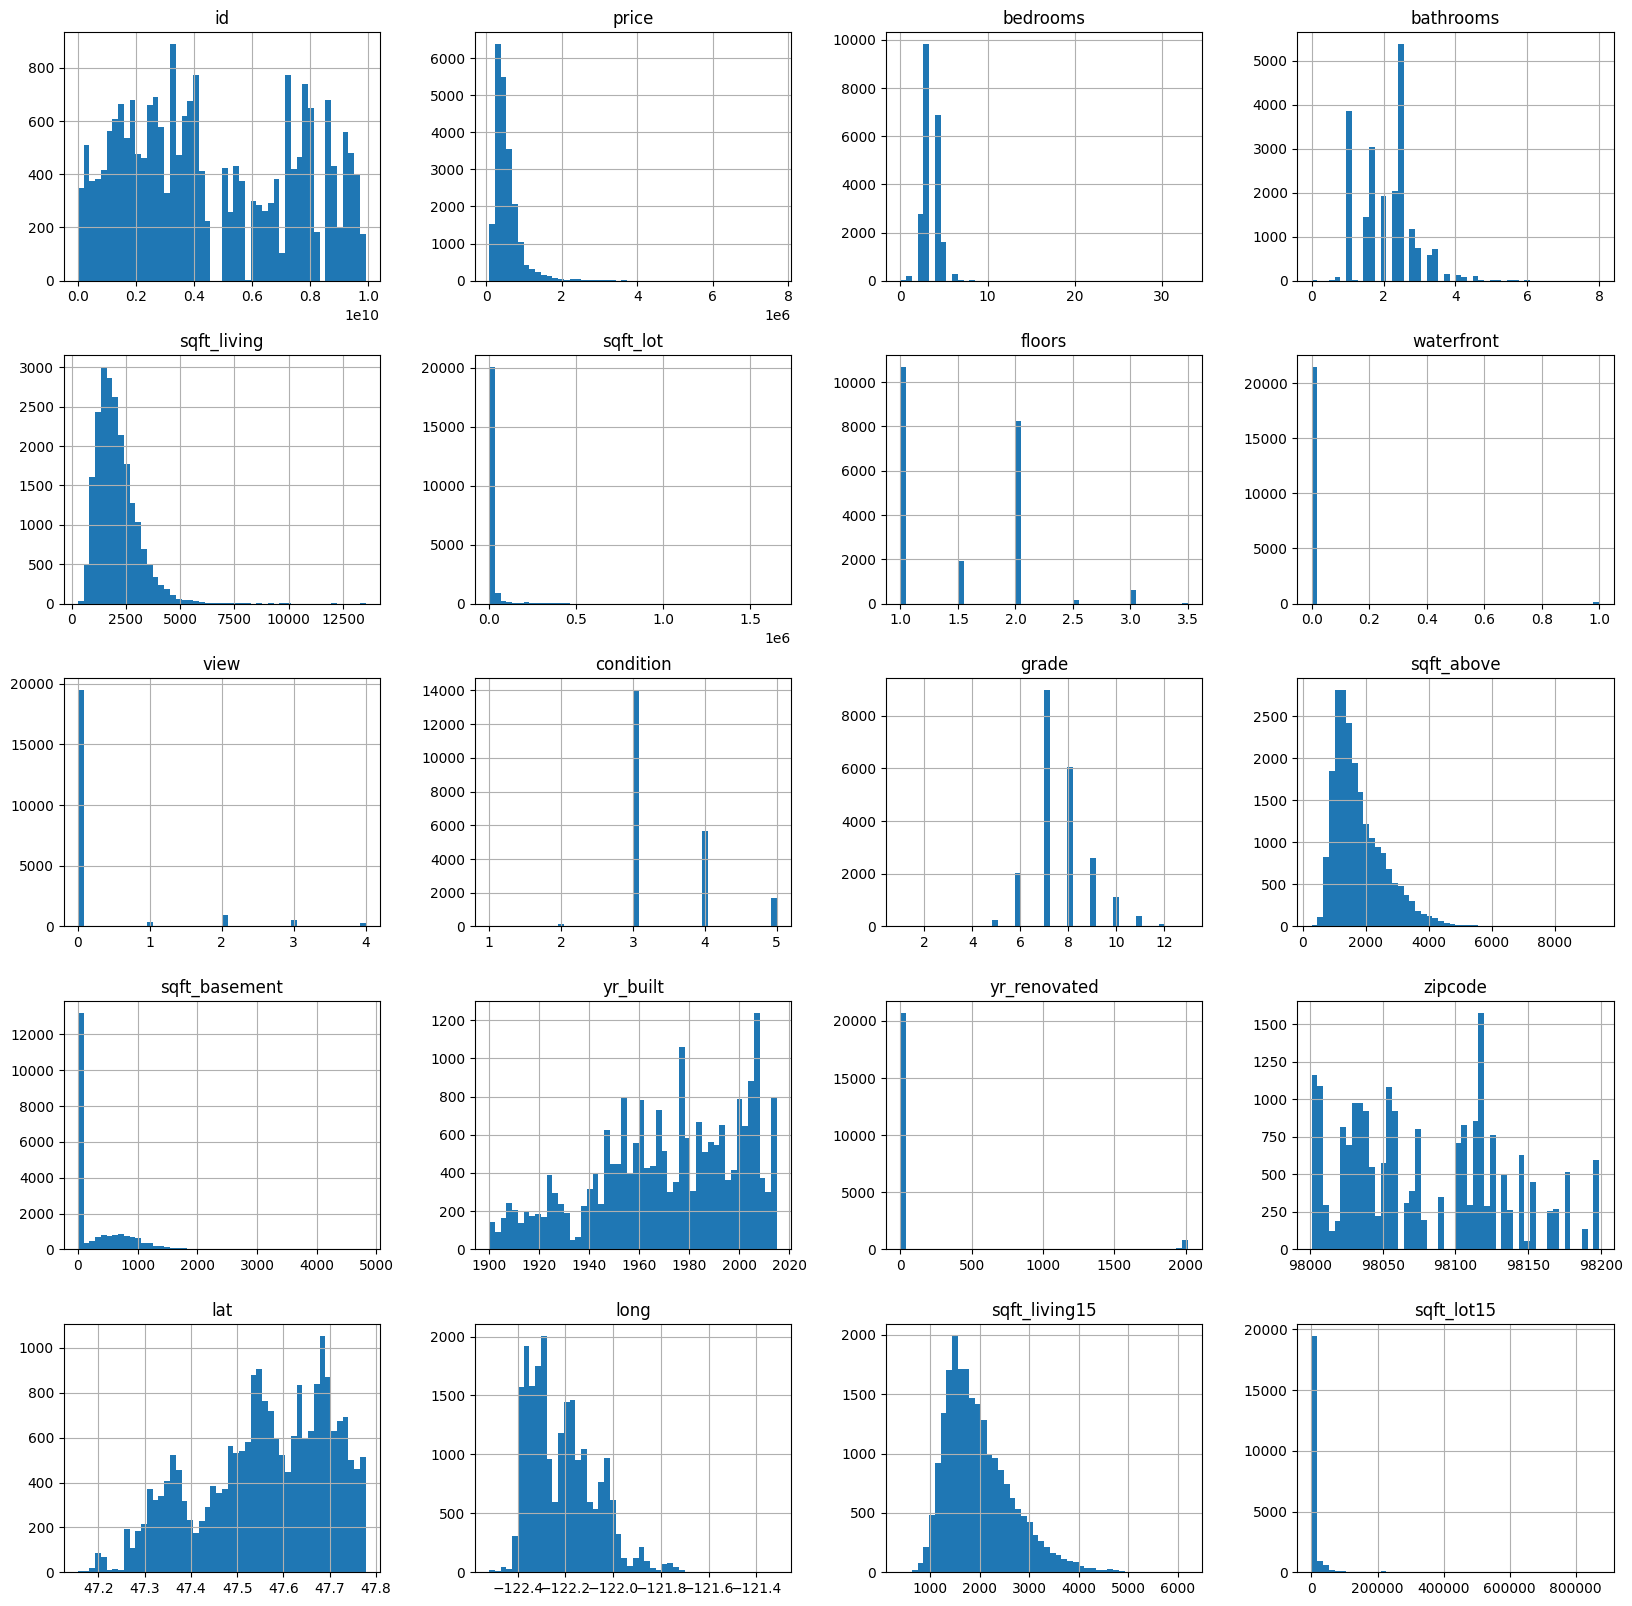

In [10]:
dataset.hist(figsize=(20, 20), bins=50)
plt.show()

### Correlation Matrix

<Axes: title={'center': 'Correlation Matrix'}>

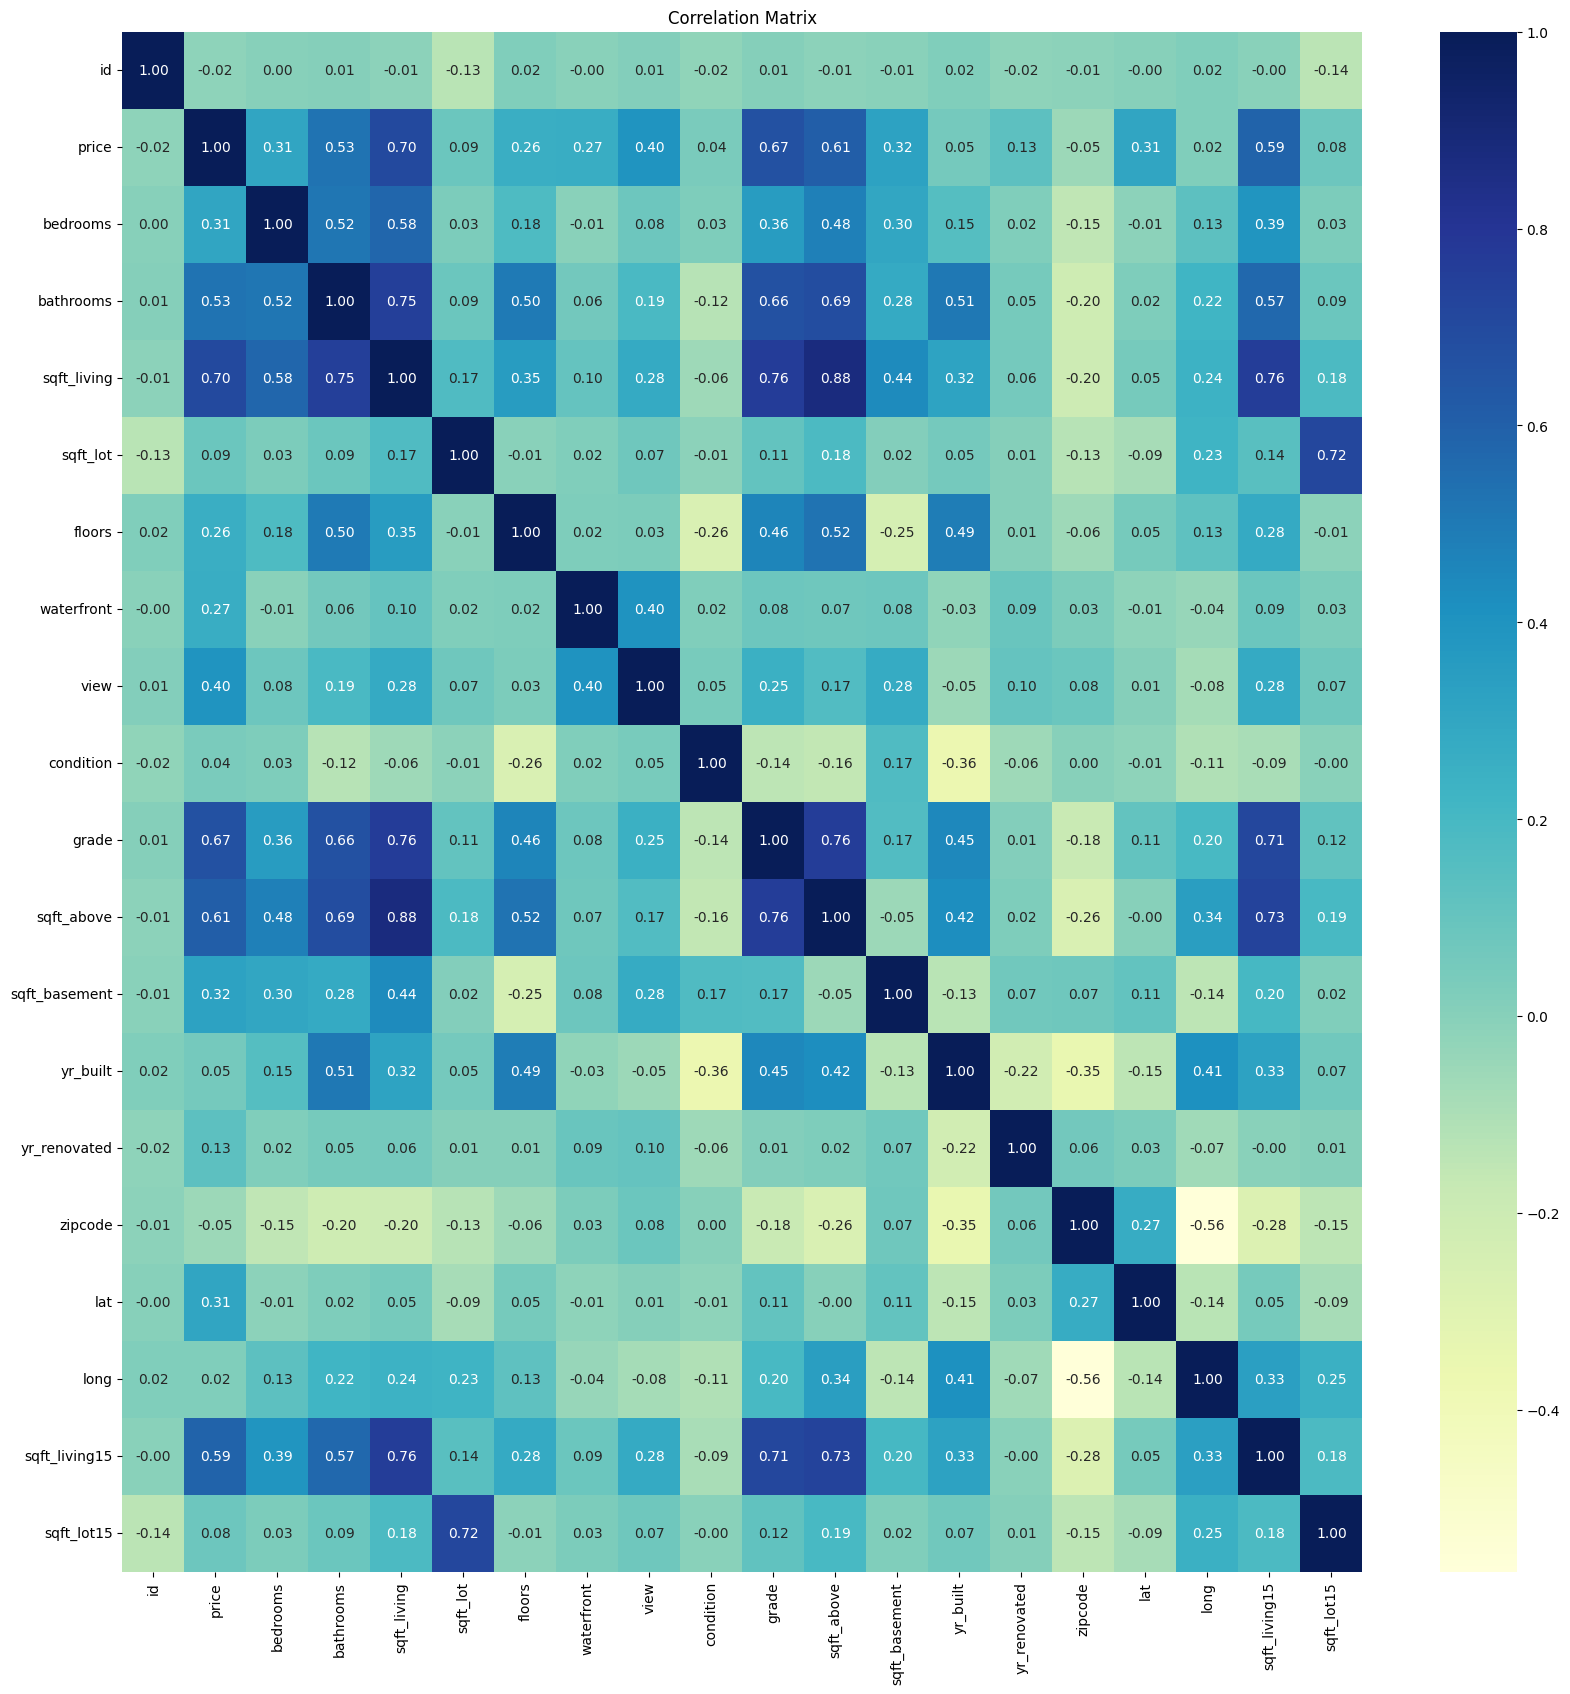

In [23]:
plt.figure(figsize=(20, 20))
plt.title("Correlation Matrix")
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt='.2f')

In [19]:
train_data= dataset[['price','bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'condition','grade','lat','long']]
print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(train_data.index)))
print('Total number of columns: {0}\n\n'.format(len(train_data.columns)))

Read dataset completed successfully.
Total number of rows: 21613


Total number of columns: 11




<Axes: >

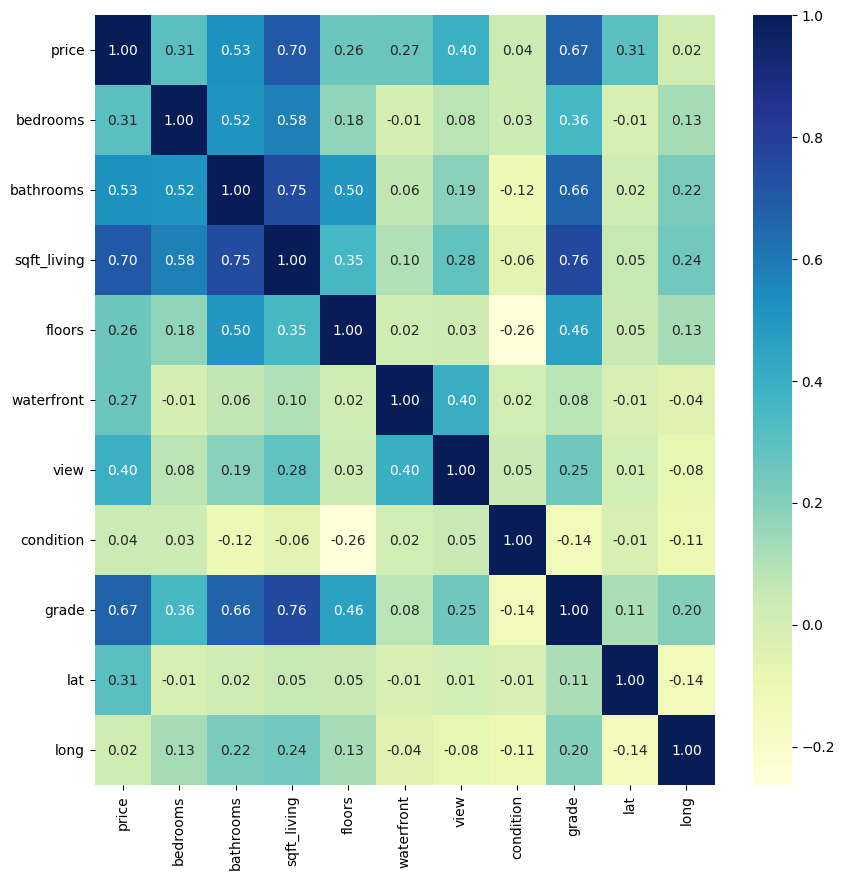

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt='.2f')

## Train Model

### Plot Functions

### ML Functions

In [39]:
def build_model(learning_rate,num_features):
    inputs=keras.Input(shape=(num_features,))
    outputs=keras.layers.Dense(units=1)(inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=learning_rate),
                  loss="mean_squared_error",
                  metrics=[keras.metrics.RootMeanSquaredError()])
    return model

def train_model(model, features, label, epochs,batch_size):
    
    history= model.fit(x=features,y=label,
                       batch_size=batch_size,
                       epochs=epochs)
    
    train_wt= model.get_weights()[0]
    train_bias= model.get_weights()[1]
    
    epochs= history.epoch
    
    hist= pd.DataFrame(history.history)
    
    rmse=hist['root_mean_squared_error']
    
    return train_wt, train_bias, epochs, rmse

def run_model(df,feature_names, label_name, learning_rate, epochs, batch_size):
    
    num_features=len(feature_names)
    features= df.loc[:, feature_names].values
    label= df[label_name].values
    
    model=build_model(learning_rate, num_features)
    model_output= train_model(model,features,label,epochs,batch_size)
    
    print('Model training completed successfully.')
    
    return model
    
    

### Train model

In [40]:
learning_rate=0.01
epochs=200
batch_size=50

features= ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view']
label= 'price'
model_initial= run_model(train_data,features,label,learning_rate,epochs,batch_size)

Epoch 1/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 420578656256.0000 - root_mean_squared_error: 648472.3125
Epoch 2/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 433385275392.0000 - root_mean_squared_error: 657791.3125
Epoch 3/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 401600675840.0000 - root_mean_squared_error: 633682.9375
Epoch 4/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 396696584192.0000 - root_mean_squared_error: 629783.1875
Epoch 5/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 369597448192.0000 - root_mean_squared_error: 607892.5625
Epoch 6/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 389824380928.0000 - root_mean_squared_error: 623994.0625
Epoch 7/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 357012570112.0000 - root_mean_squared_error: 597400.8125
Epoch 8/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 345603112960.0000 - root_mean_squared_error: 587767.9375
Epoch 9/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - l

### Validate Model

In [41]:
def format_currency(value):
    return "${:,.0f}".format(value) 

def build_batch(df, batch_size):
    batch= df.sample(n=batch_size).copy()
    batch.set_index(np.arange(batch_size), inplace=True)
    return batch

def predict_price(model,df,features,label,batch_size):
    batch= build_batch(df, batch_size)
    
    predicted_values = model.predict_on_batch(x=batch.loc[:,features].values)
    
    data={"predicted_price":[], "observed_price":[], "L1_Loss":[],
          features[0]:[], features[1]:[]}
    
    for i in range(batch_size):
        predicted= predicted_values[i][0]
        observed= batch.at[i,label]
        data["predicted_price"].append(format_currency(predicted))
        data["observed_price"].append(format_currency(observed))
        data["L1_Loss"].append(format_currency(abs(observed - predicted)))
        data[features[0]].append(batch.at[i, features[0]])
        data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))
        
        output_df = pd.DataFrame(data)
        return output_df
    
def show_predictions(output):
    header = "-" * 80
    banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
    print(banner)
    print(output)
    return   

### Make prediction

In [ ]:
output = predict_price(model_initial, train_data, features, label,batch_size)
show_predictions(output)


--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
  predicted_price observed_price  L1_Loss  bedrooms bathrooms
0        $572,891       $524,000  $48,891         4      2.25
